# [LAB-13] 2. 시계열 데이터의 평활

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기

- 1단원과 같은 월간 항공 승객 수 데이터를 사용한다.

In [2]:
origin = load_data('air_passengers')
origin

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


### 3. 시계열 인덱스 설정

In [3]:
df = my_ts.set_index(origin, 'Month', freq = 'MS')

print('인덱스 간격(freq) : ', df.index.freqstr)

df.head()

인덱스 간격(freq) :  MS


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## #02. 이동평균법 (Moving Average)

### 1. 창 크기를 바꿔가며 관찰하기

창 크기 3 · 6 · 12를 각각 계산해 컬럼으로 쌓은 뒤 원본과 나란히 그린다.

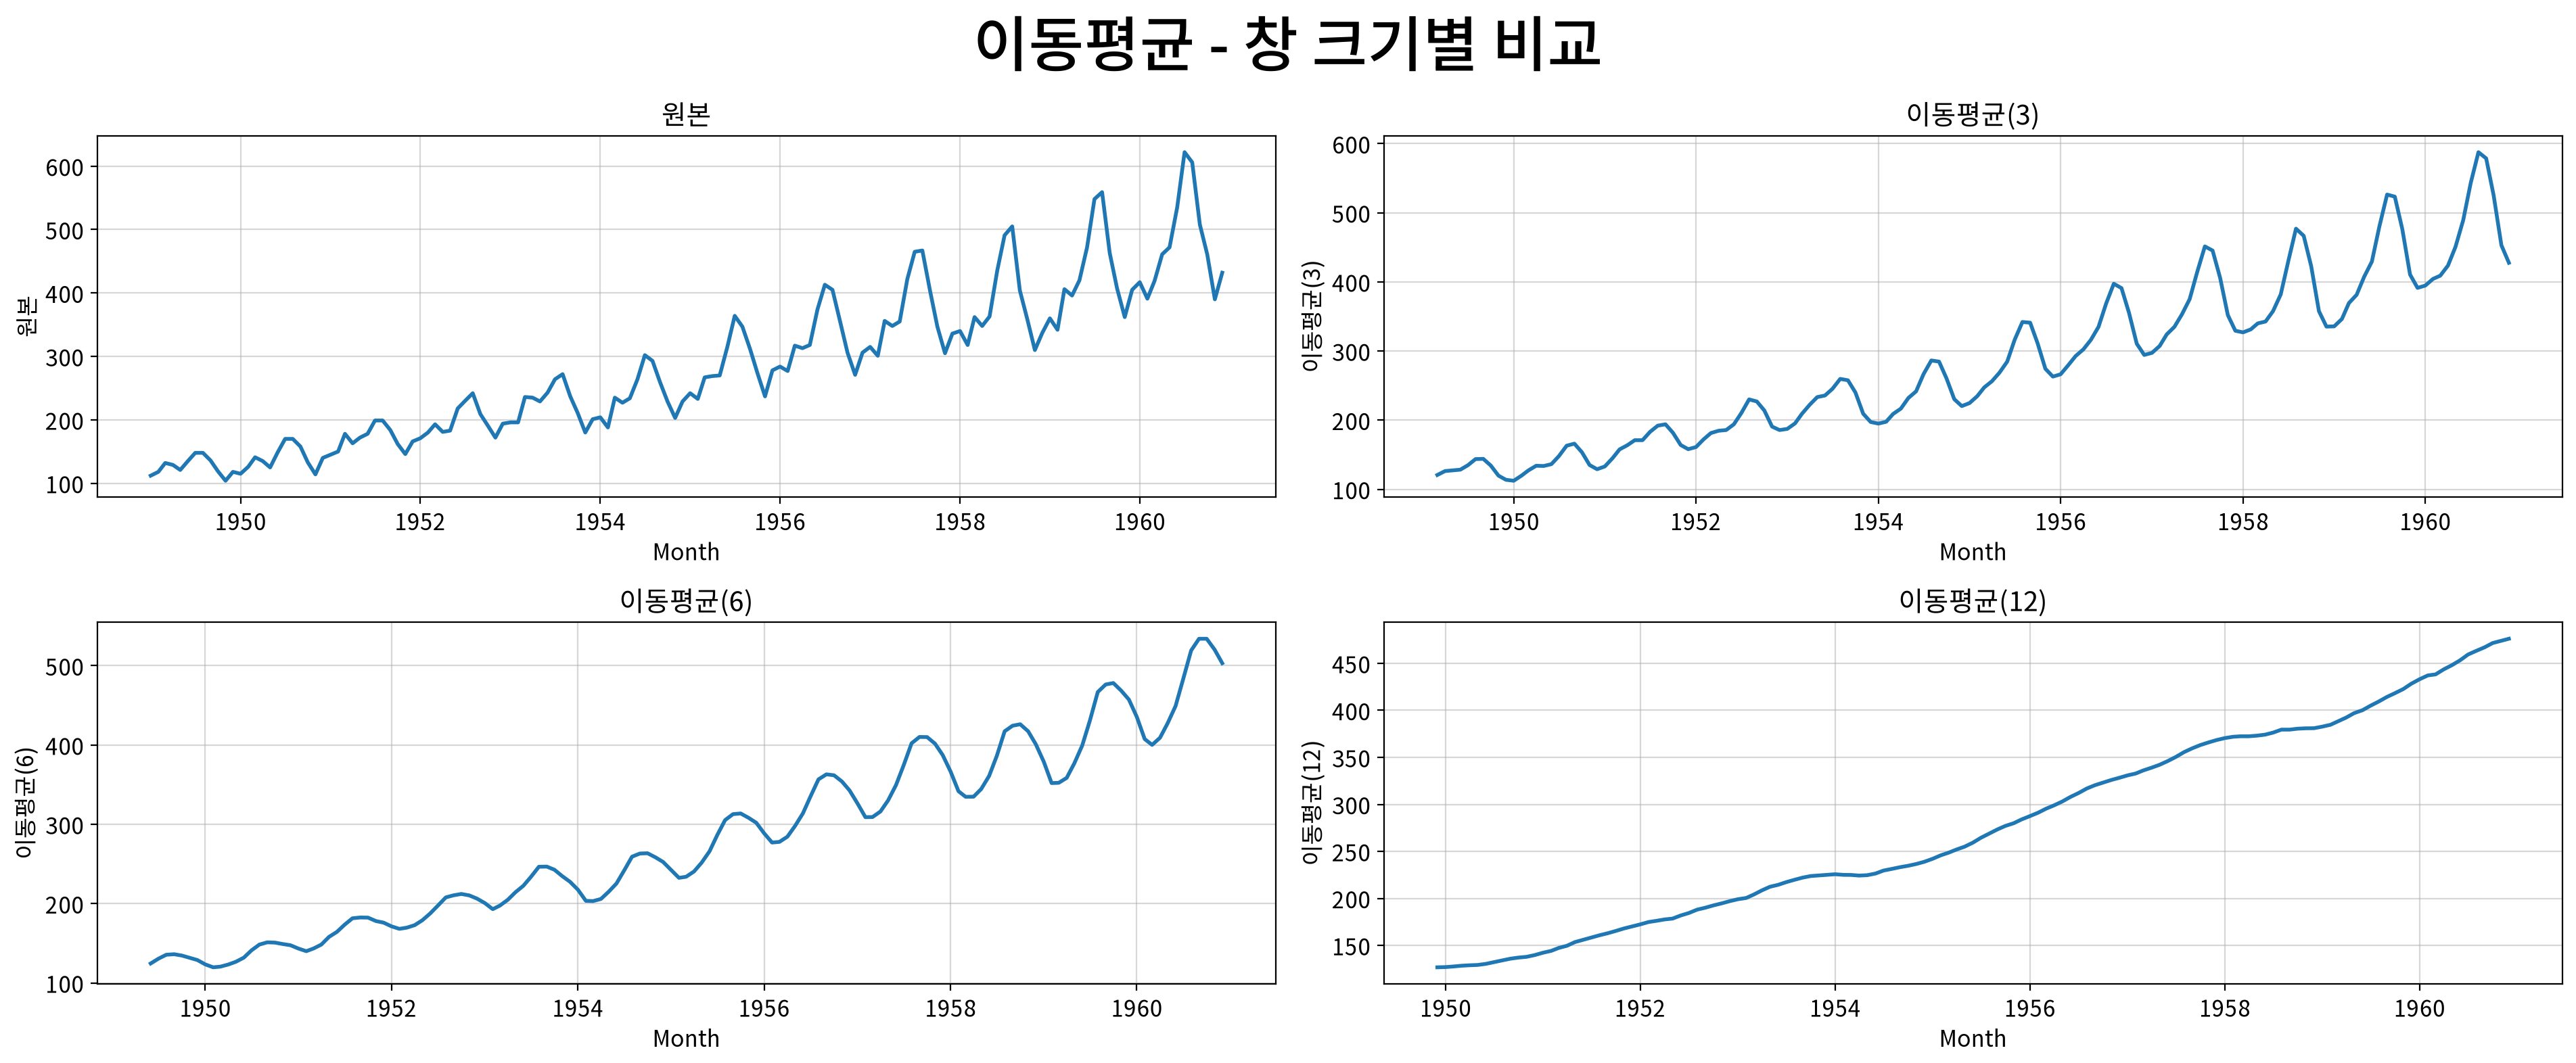

,원본,이동평균(3),이동평균(6),이동평균(12)
Month,,,,
1960-10-01,461,525.000,534.000,471.583
1960-11-01,390,453.000,520.333,473.917
1960-12-01,432,427.667,503.167,476.167


In [4]:
ma = DataFrame({'원본' : df['Passengers']})

for k in (3, 6, 12):
    ma[f'이동평균({k})'] = df['Passengers'].rolling(k).mean()

# 원본 + 창 3개 = 4칸이므로, 2행 2열 격자에 한 칸씩 그린다.
fig, ax = my_plot.init(rows = 2, cols = 2, width=960, height=400, title = '이동평균 - 창 크기별 비교')

for i, col in enumerate(ma.columns):
    my_plot.lineplot(x=ma.index, y=ma[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

ma.tail(3)

#### 💡 인사이트

| 창 크기 | 그래프의 모습 | 무엇이 보이는가 |
|---|---|---|
| 원본 | 매년 봉우리가 뚜렷 | 계절성과 추세가 섞여 있다 |
| 3 | 거의 원본과 비슷 | 잡음만 살짝 지워졌다 |
| 6 | 봉우리가 절반 크기로 | 계절성이 **부분적으로** 지워졌다 |
| **12** | **봉우리가 거의 사라지고 매끈한 우상향 곡선** | **추세만 남았다** |

> ★ **창 크기를 계절 주기와 같게(12) 잡으면 계절성이 완전히 지워진다.**
>
> 1년치를 평균 내면 성수기와 비수기가 서로 상쇄되기 때문이다.
> 그래서 이동평균은 **추세를 뽑아내는 표준적인 방법**이며,
> 다음 단원(13-3)에서 배울 시계열 분해도 내부적으로 바로 이 계산을 사용한다.

> ⚠️ **창 크기를 6으로 잡으면 안 되는 이유**
> 6개월 평균은 반 년치만 상쇄하므로 봉우리가 절반만 지워지고
> **원래 없던 6개월짜리 주기가 있는 것처럼 보인다.**
> 창 크기는 반드시 **계절 주기(또는 그 배수)** 로 잡아야 한다.

### 2. 정상시계열에 적용 실험

차분된 데이터에 적용하면 1단원에서 확보한 정상 시계열(로그 + 1차 차분 + 계절차분)에도 적용해 본다.

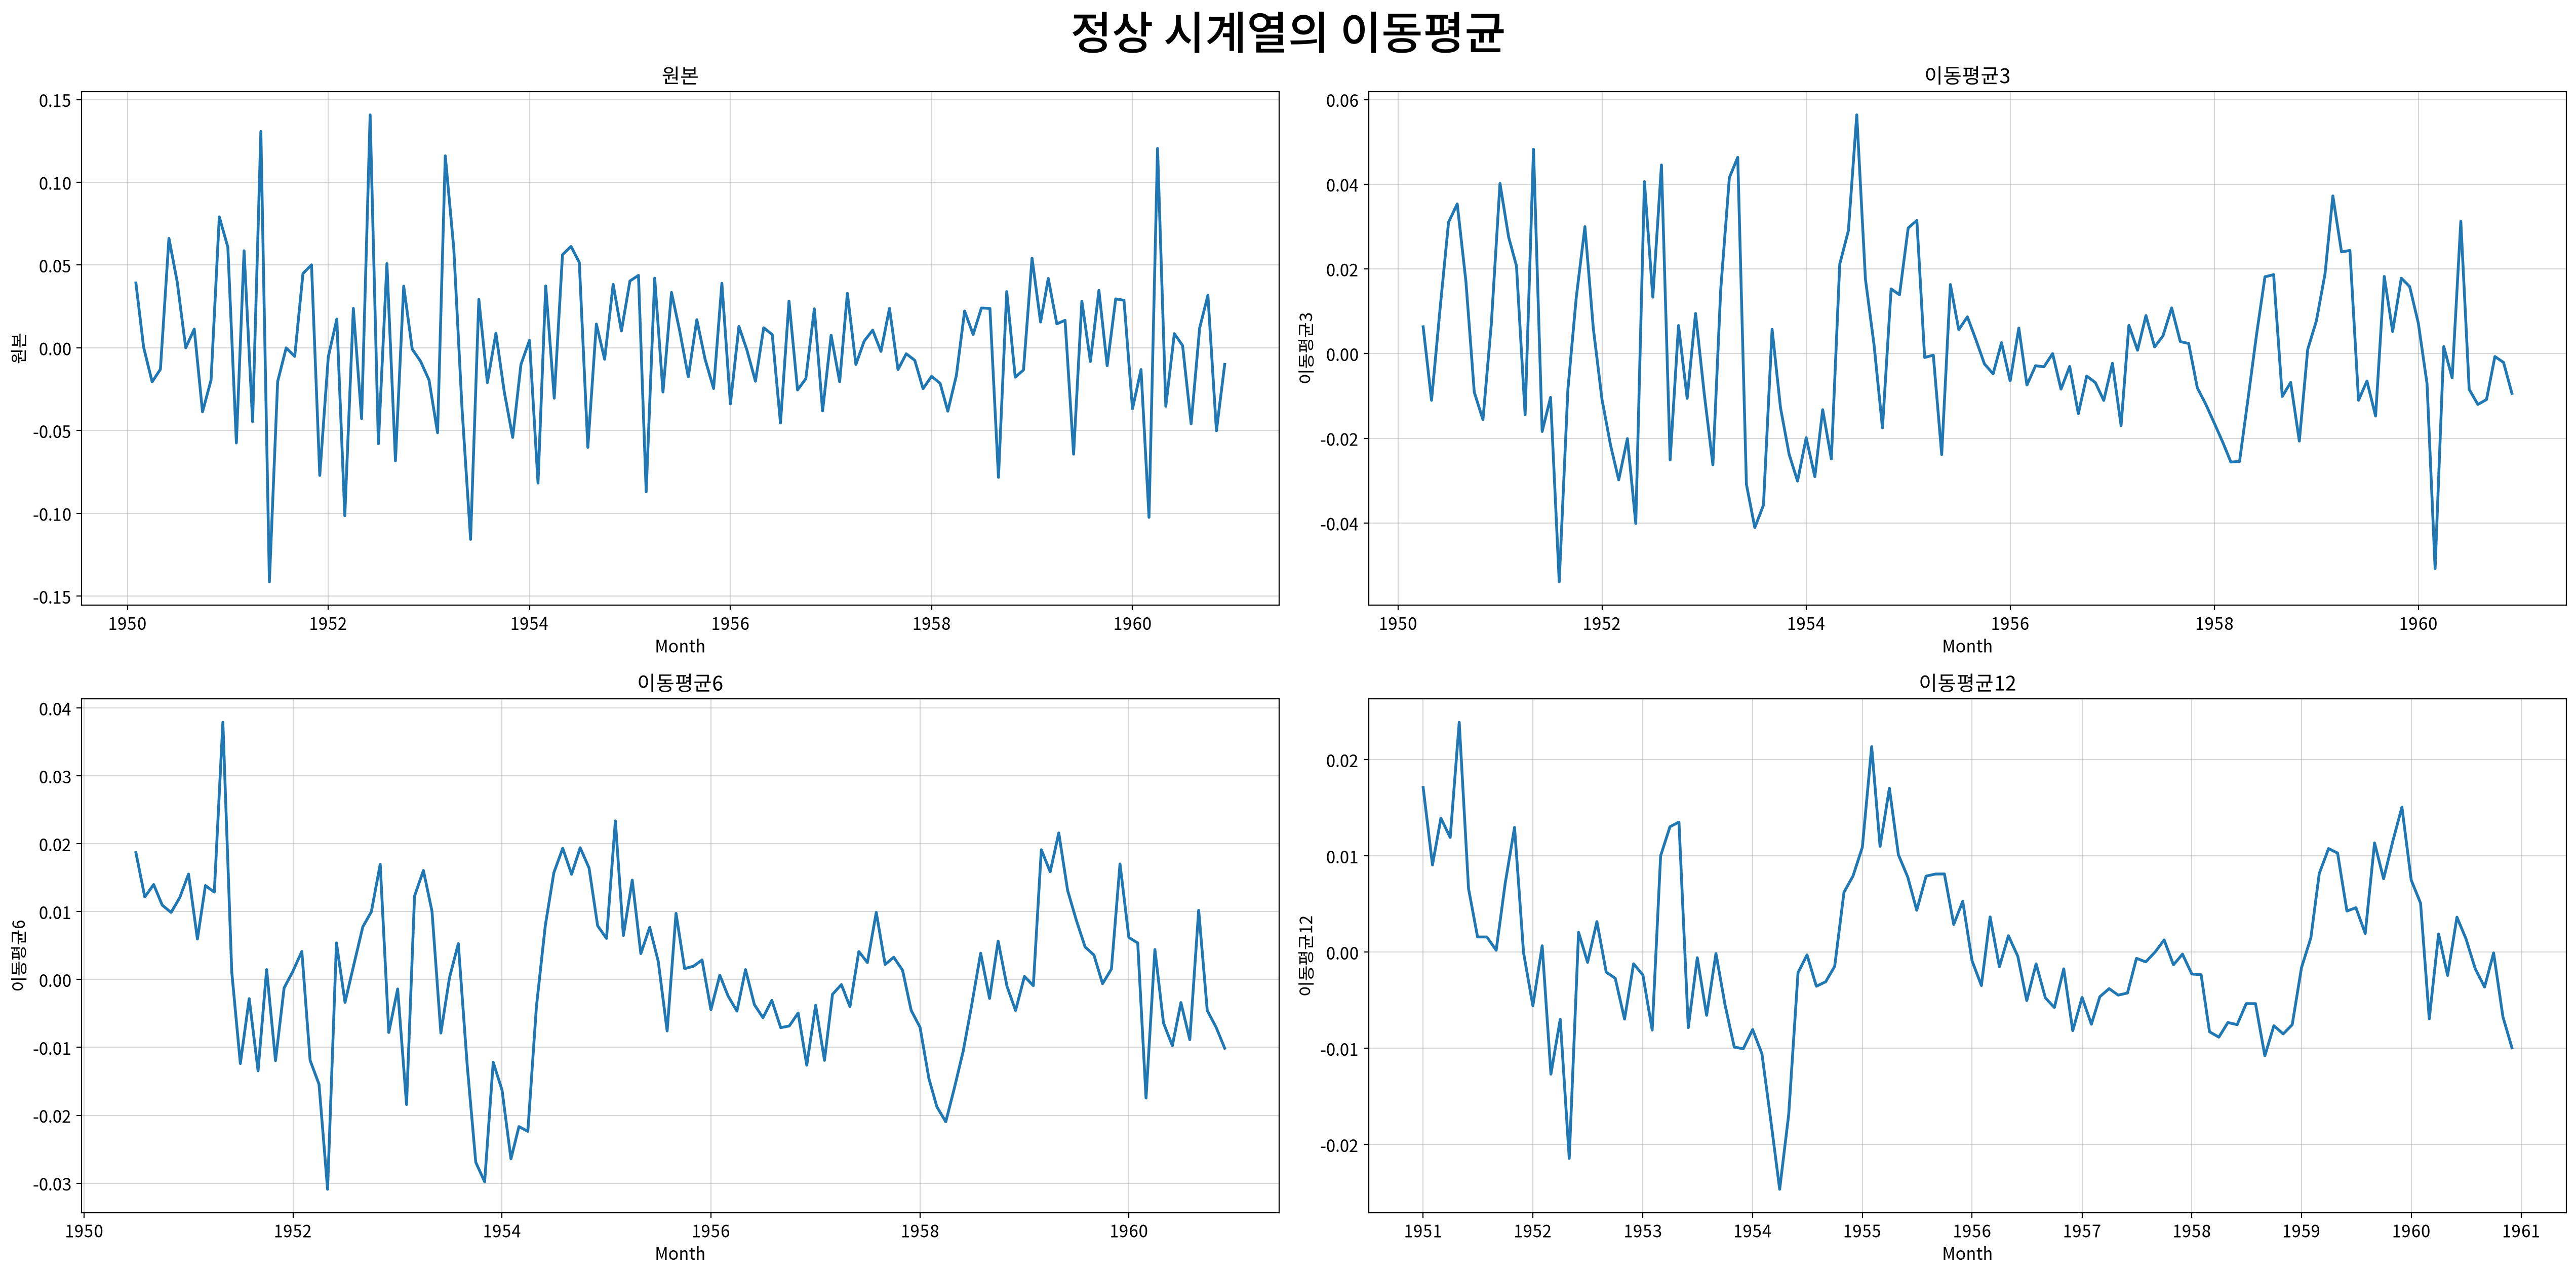

In [5]:
# 1단원에서 확보한 정상 시계열(로그 변환 -> 1차 차분 -> 계절차분)을 한 줄로 적용

stationary = my_ts.transform(df, 'Passengers', log = True, diff = 1, seasonal_diff=1, period=12)

ma_stationary = DataFrame({'원본' : stationary})

for k in (3, 6, 12):
    ma_stationary[f'이동평균{k}'] = stationary.rolling(k).mean()

fig, ax = my_plot.init(width=1280, height=640, title='정상 시계열의 이동평균', rows=2, cols=2)

for i, col in enumerate(ma_stationary.columns):
    my_plot.lineplot(x=ma_stationary.index, y=ma_stationary[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

#### 💡 인사이트

- 원본과 달리 이동평균 곡선이 **0 주변의 수평선**에 가깝다.
- 창을 키워도 뚜렷한 흐름이 나타나지 않는다 → **더 이상 뽑아낼 추세가 없다.**

> 이것이 바로 "정상 시계열"의 모습이다.
> 평활을 해도 남는 구조가 없다는 것은 **잡음만 남았다**는 뜻이고,
> 그래야 ARIMA 같은 모형이 제대로 작동한다.

## #03. 지수평활법 (Exponential Smoothing)

### 1. 기간을 바꿔가며 관찰하기

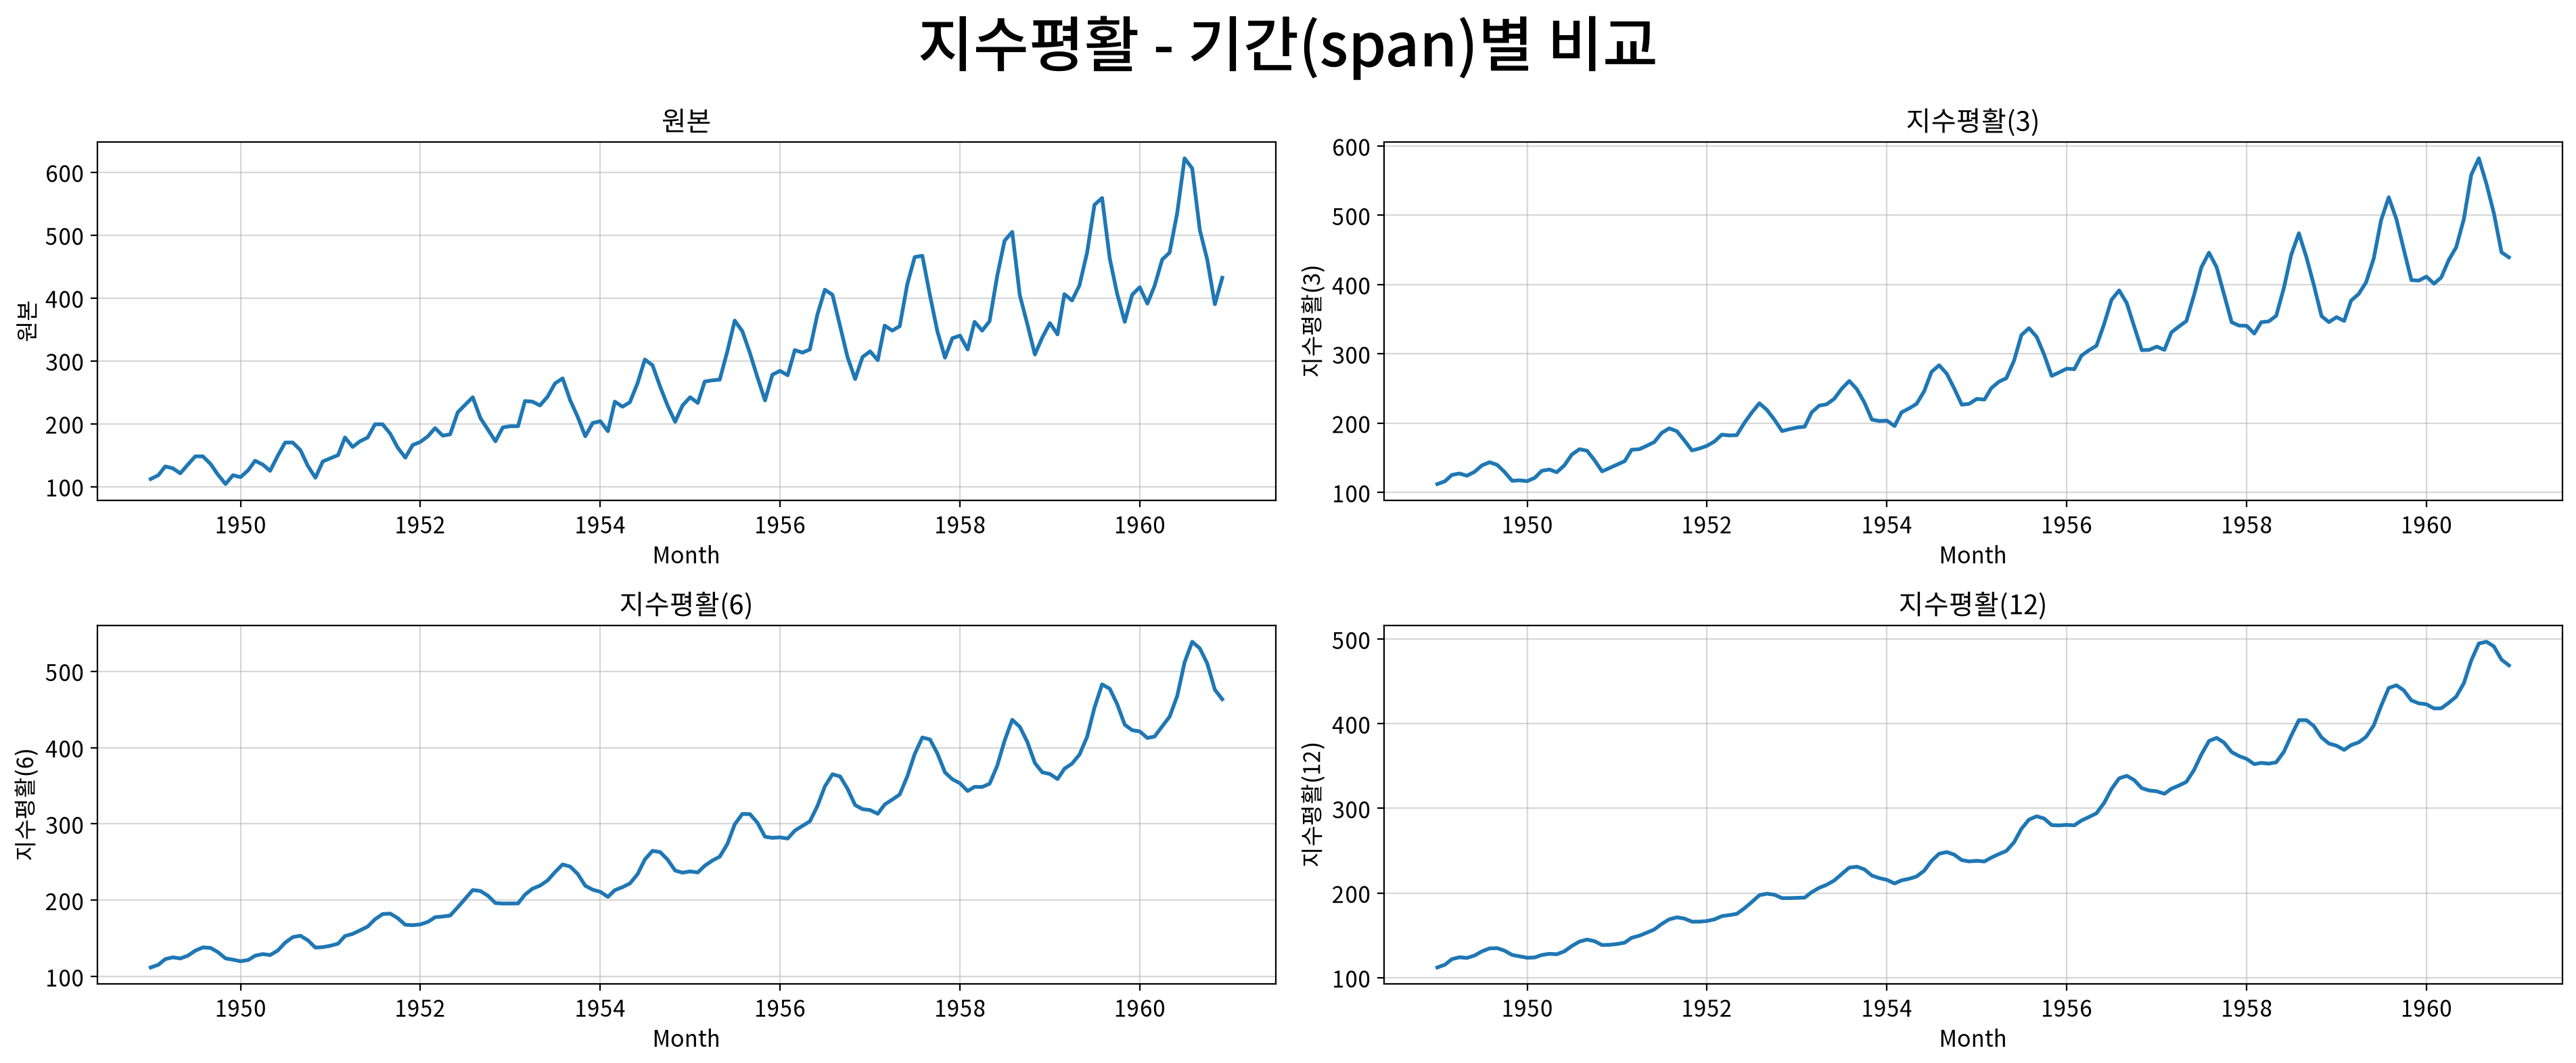

,원본,지수평활(3),지수평활(6),지수평활(12)
Month,,,,
1960-10-01,461,503.024,510.158,491.389
1960-11-01,390,446.512,475.827,475.791
1960-12-01,432,439.256,463.305,469.054


In [6]:
ew = DataFrame({'원본' : df['Passengers']})

for p in (3, 6, 12):
    # 첫 인자는 com(중심 질량)이므로, span= 을 반드시 키워드로 명시한다.
    ew[f'지수평활({p})'] = df['Passengers'].ewm(span=p).mean()

fig, ax = my_plot.init(rows=2, cols=2, title = '지수평활 - 기간(span)별 비교', width=960, height=400)

for i, col in enumerate(ew.columns):
    my_plot.lineplot(x=ew.index, y=ew[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

ew.tail(3)

#### 💡 인사이트

- span이 커질수록 곡선이 부드러워지는 것은 이동평균과 같다.
- 그러나 **span=12에서도 봉우리가 완전히 사라지지 않는다.**
  최근 값에 가중치를 주기 때문에 성수기의 흔적이 남는 것이다.

## #04. 두 방법을 직접 겹쳐서 비교

### 1. 원본, 이동평균, 지수평활을 한번에 시각화

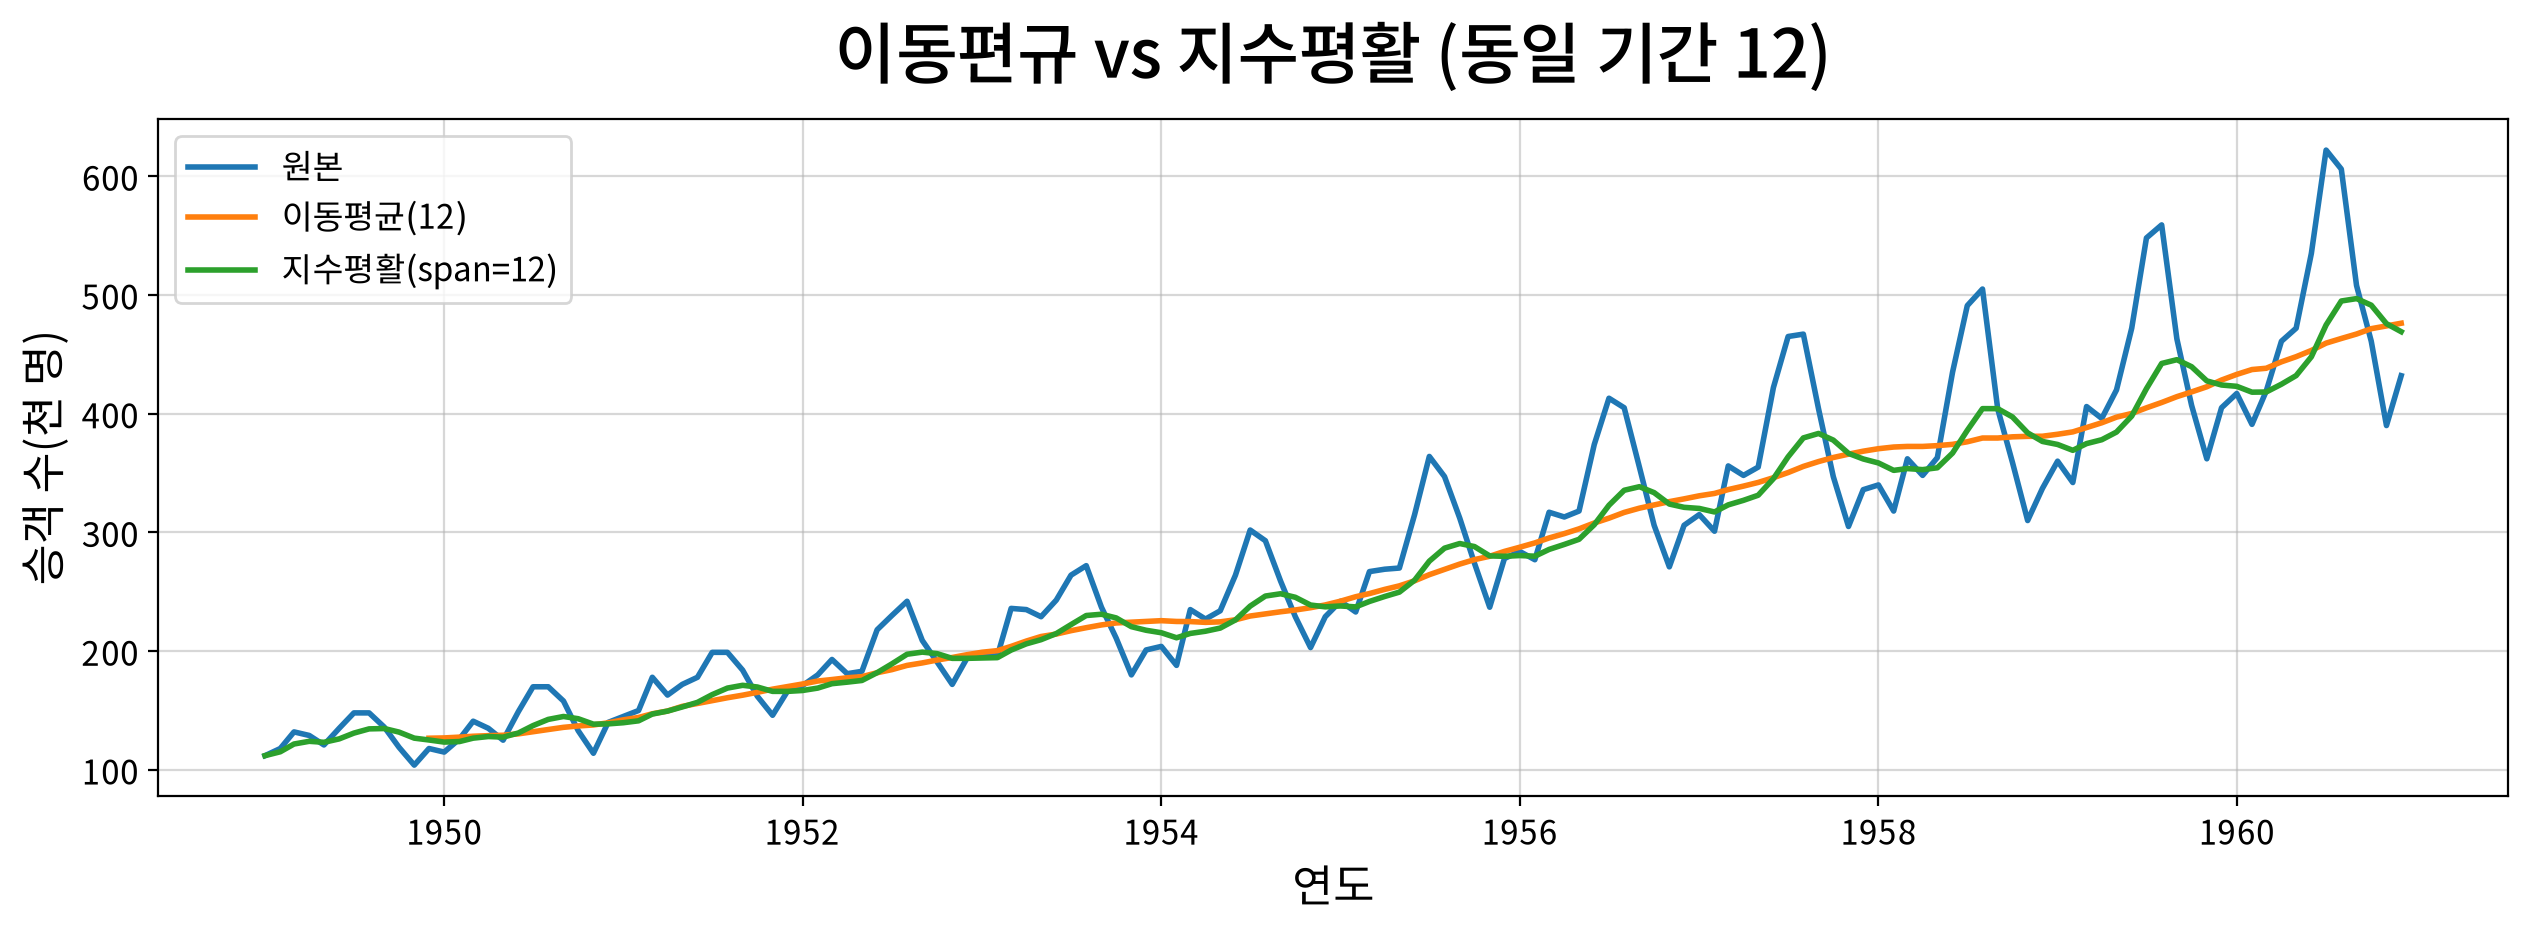

In [7]:
compare = DataFrame({
    '원본' : df['Passengers'],
    '이동평균(12)' : df['Passengers'].rolling(12).mean(),
    '지수평활(span=12)' : df['Passengers'].ewm(span=12).mean()
})

fig, ax = my_plot.init(width=1280, height=480, title='이동편규 vs 지수평활 (동일 기간 12)', xlabel='연도', ylabel='승객 수(쳔 명)')

for col in compare.columns:
    my_plot.lineplot(x=compare.index, y=compare[col], ax=ax, label=col)

ax.legend()
my_plot.show()

#### 💡 인사이트

- **이동평균(주황)** 은 봉우리가 완전히 사라진 매끈한 곡선이다. → 추세 그 자체
- **지수평활(초록)** 은 봉우리를 따라 출렁이면서 원본을 바짝 뒤쫓는다. → 현재 상태 추적
- 지수평활은 원본보다 **약간 오른쪽으로 밀려 있다.** 과거를 반영하기 때문에 생기는 **지연(lag)** 이다.

> 같은 기간(12)을 줬는데도 결과가 이렇게 다르다.
> **"평활 강도"가 아니라 "무엇을 보려는가"로 방법을 고른다.**

## #05. 모듈화 기능 확인

### 1. 원본+이동평균+이동표준편차 시각화

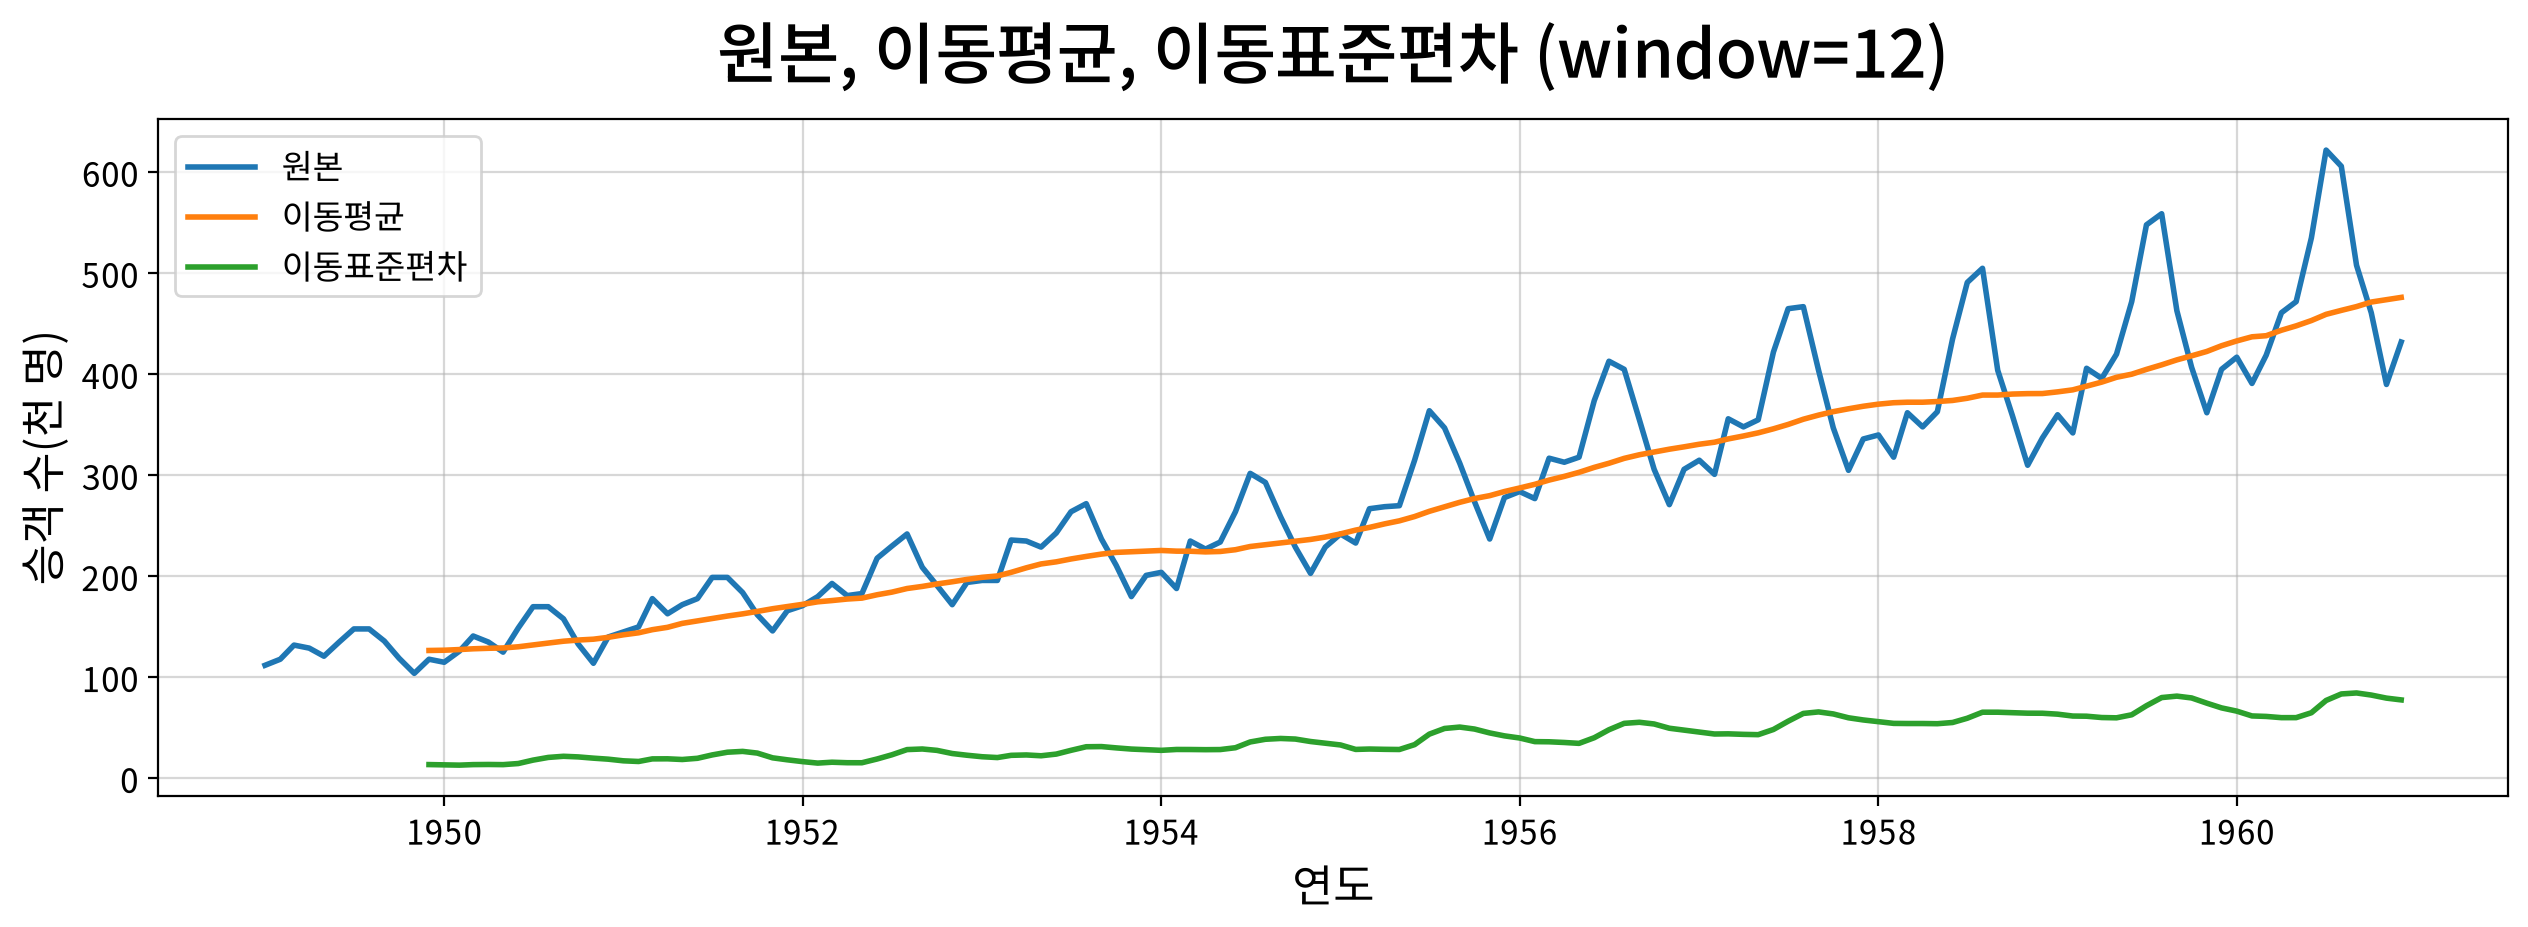

,원본,이동평균,이동표준편차
Month,,,
1960-10-01,461,471.583,82.542
1960-11-01,390,473.917,79.502
1960-12-01,432,476.167,77.737


In [8]:
# 창 크기는 계절 주기 (12)로 잡는다.

rolling = my_ts.plot_rolling(df, 12, 'Passengers', xlabel='연도', ylabel='승객 수(천 명)')

rolling.tail(3)

### 2. 정상시계열+이동평균+이동표준편차 시각화

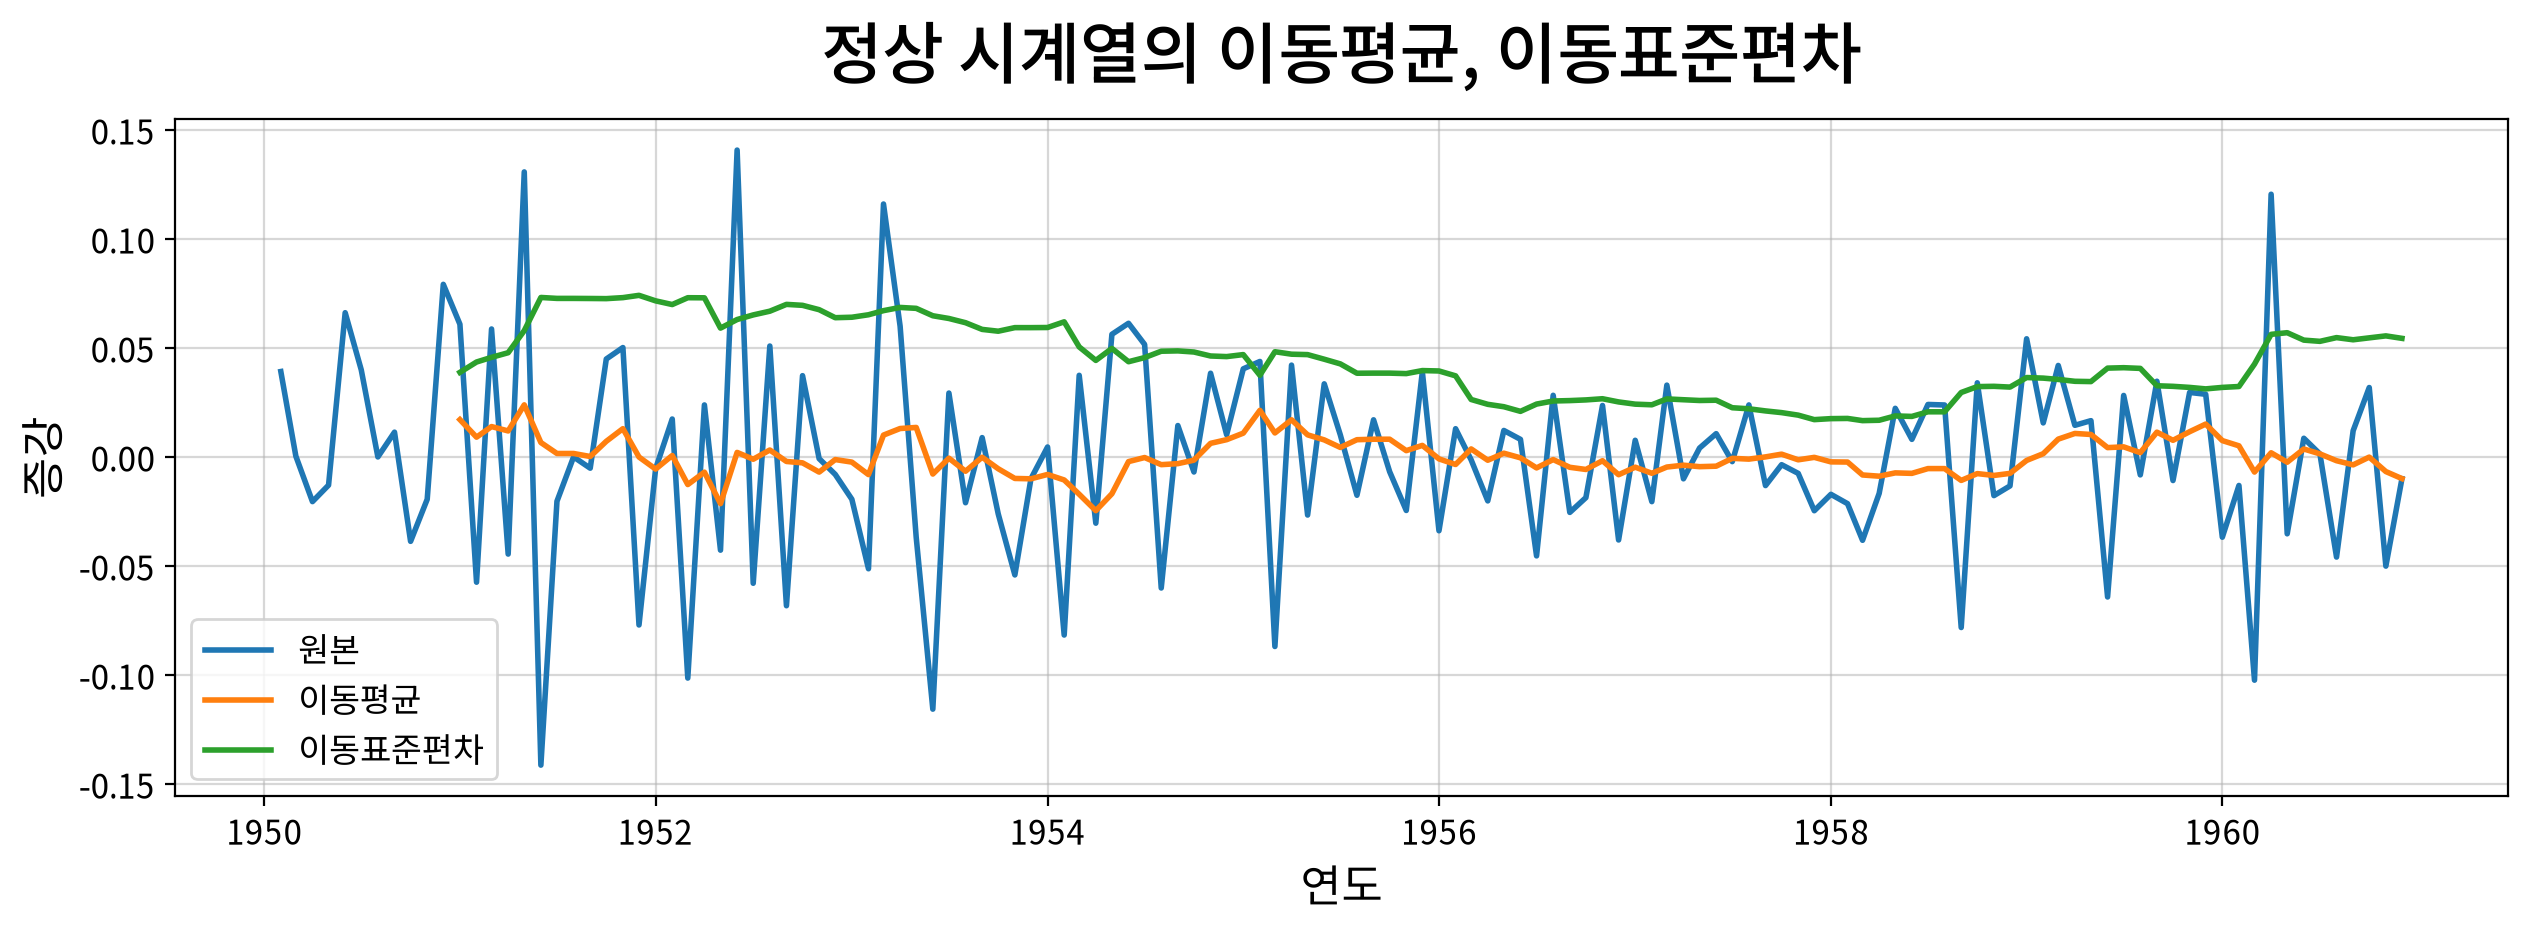

,원본,이동평균,이동표준편차
Month,,,
1960-10-01,0.032,-0.000,0.055
1960-11-01,-0.050,-0.007,0.056
1960-12-01,-0.010,-0.010,0.054


In [9]:
# 같은 그림을 정상 시계열에도 그려 비교한다.
rolling_stationary = my_ts.plot_rolling(stationary, 12, title = '정상 시계열의 이동평균, 이동표준편차', xlabel='연도', ylabel='증강')

rolling_stationary.tail(3)

### 3. 격자 형태로 이동평균 창 크기별 비교

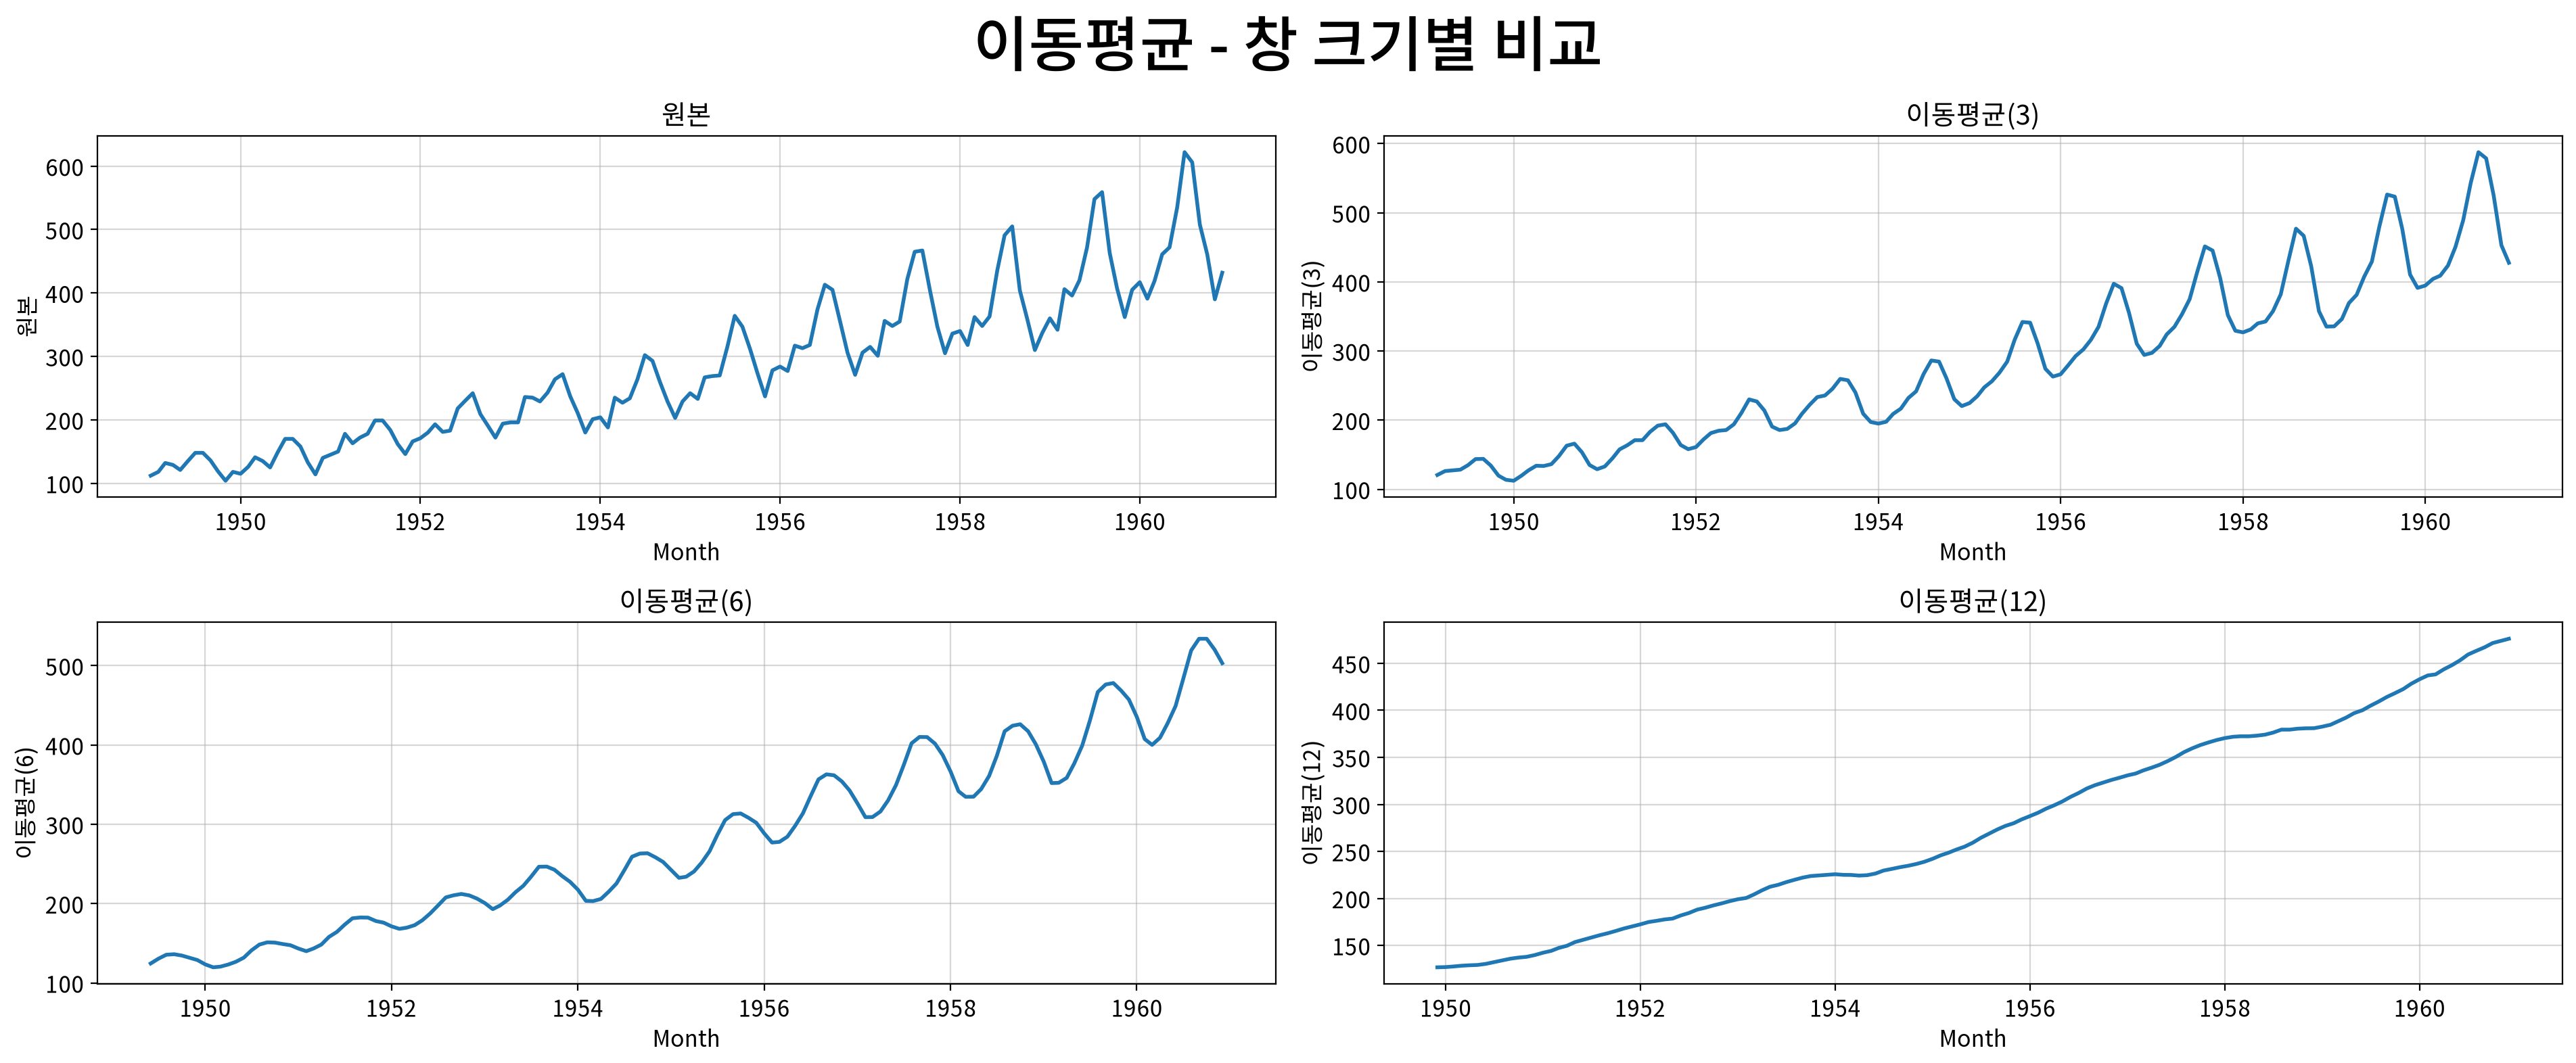

,원본,이동평균(3),이동평균(6),이동평균(12)
Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,NaN,NaN,NaN
1949-03-01,132,120.667,NaN,NaN
1949-04-01,129,126.333,NaN,NaN
1949-05-01,121,127.333,NaN,NaN
...,...,...,...,...
1960-08-01,606,587.667,519.167,463.333
1960-09-01,508,578.667,534.000,467.083
1960-10-01,461,525.000,534.000,471.583


In [10]:
ma_result = my_ts.compare_smoothing(df, (3, 6, 12), 'Passengers', method='ma', title = '이동평균 - 창 크기별 비교')
ma_result

### 4. 격자 형태로 지수평활 span 별 비교

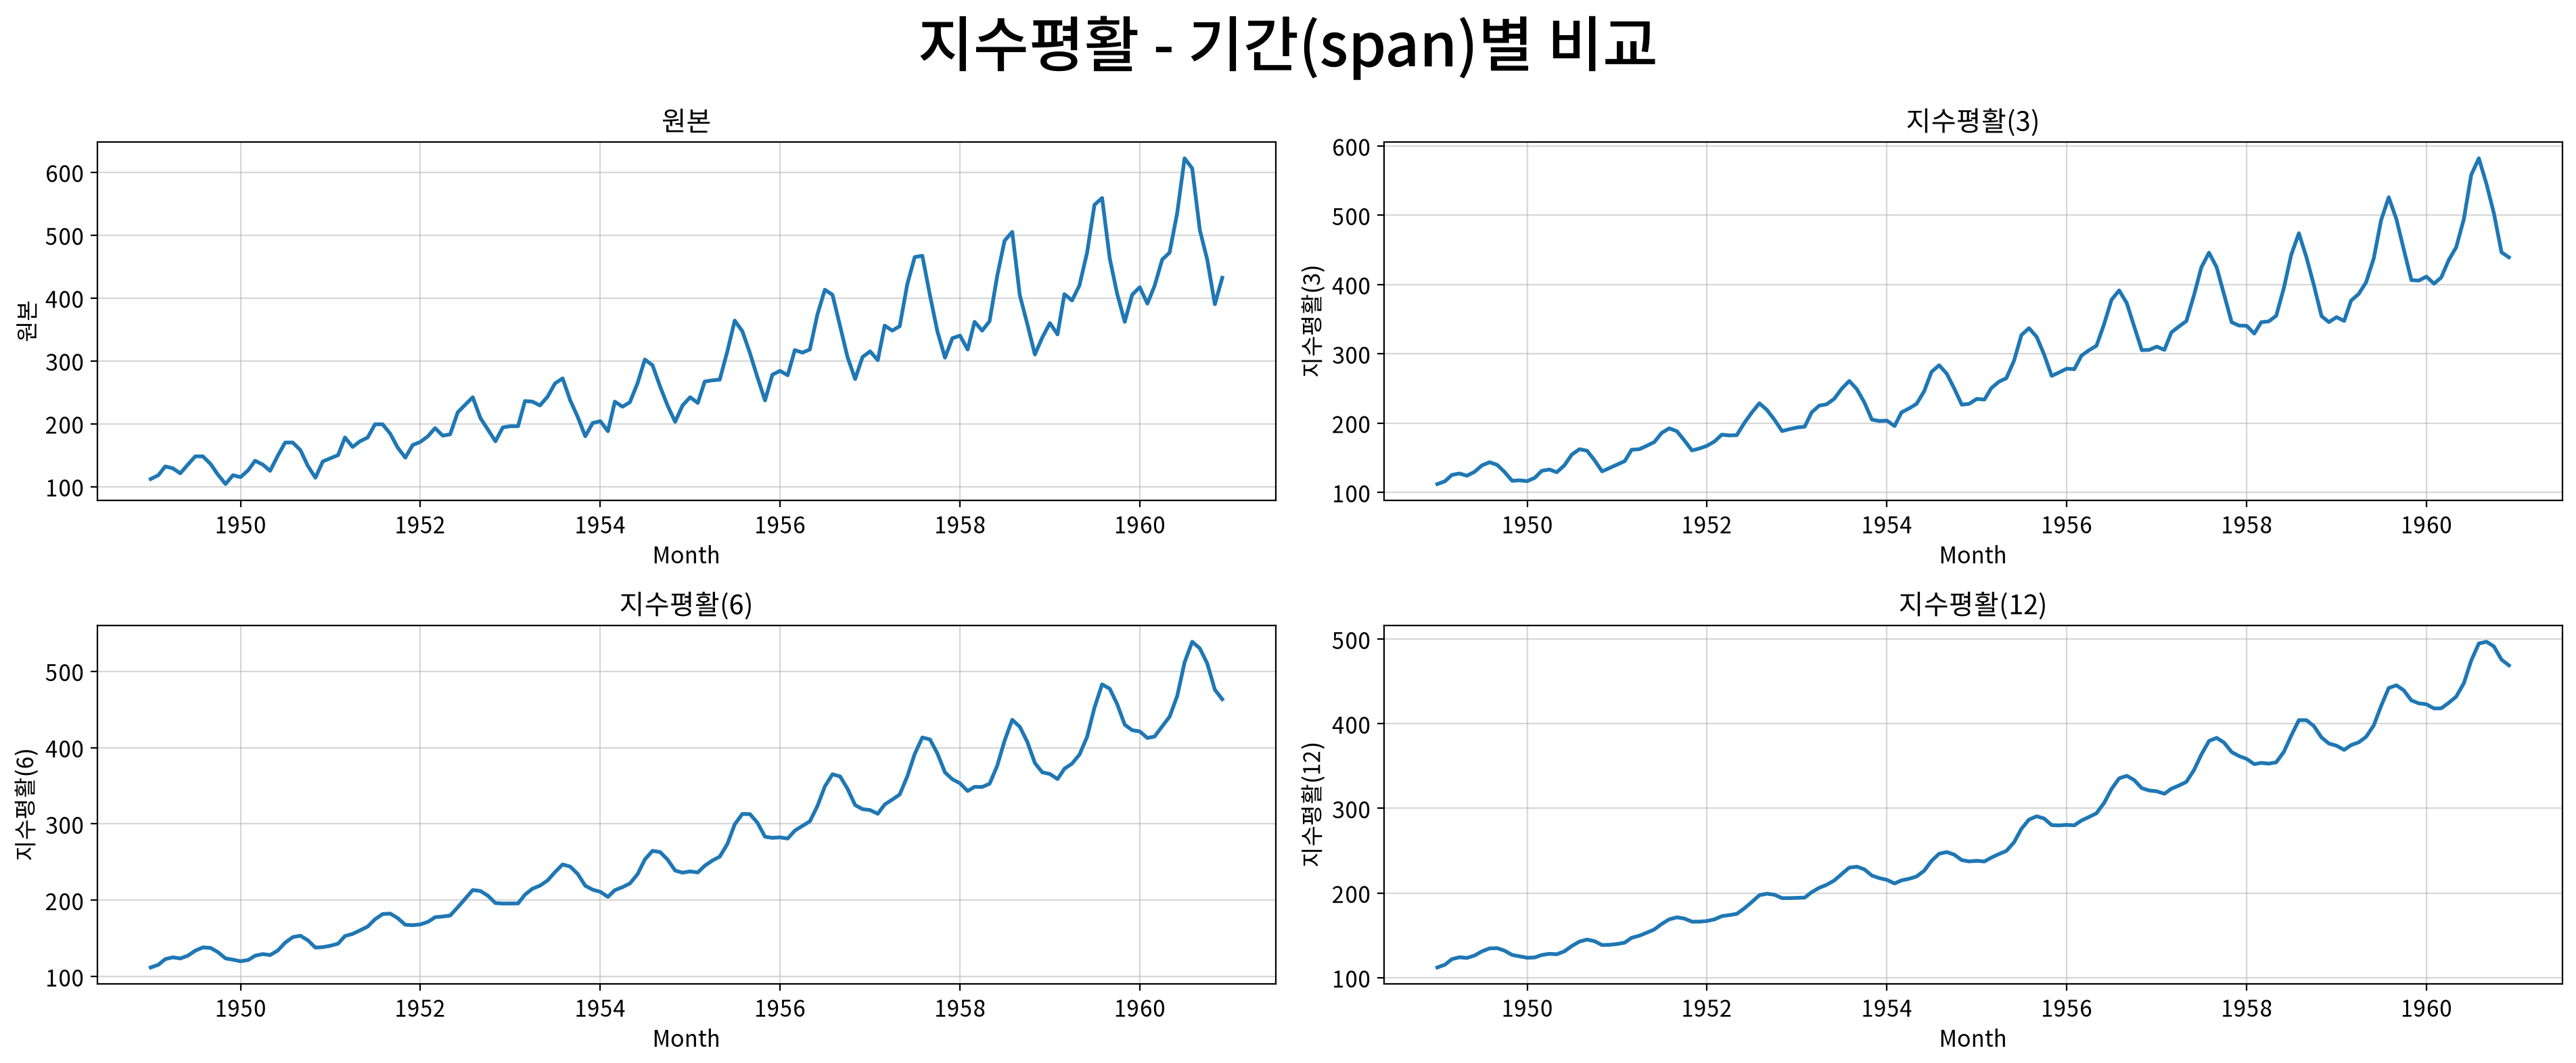

,원본,지수평활(3),지수평활(6),지수평활(12)
Month,,,,
1949-01-01,112,112.000,112.000,112.000
1949-02-01,118,116.000,115.500,115.250
1949-03-01,132,125.143,122.917,121.788
1949-04-01,129,127.200,125.267,124.064
1949-05-01,121,124.000,123.769,123.232
...,...,...,...,...
1960-08-01,606,582.096,538.549,494.899
1960-09-01,508,545.048,529.821,496.914
1960-10-01,461,503.024,510.158,491.389


In [11]:
ewm_result = my_ts.compare_smoothing(df, (3, 6, 12), 'Passengers', method='ewm', title = '지수평활 - 기간(span)별 비교')
ewm_result

### 5. 같은 기간 12로 두 방법을 한 축에 겹쳐 비교

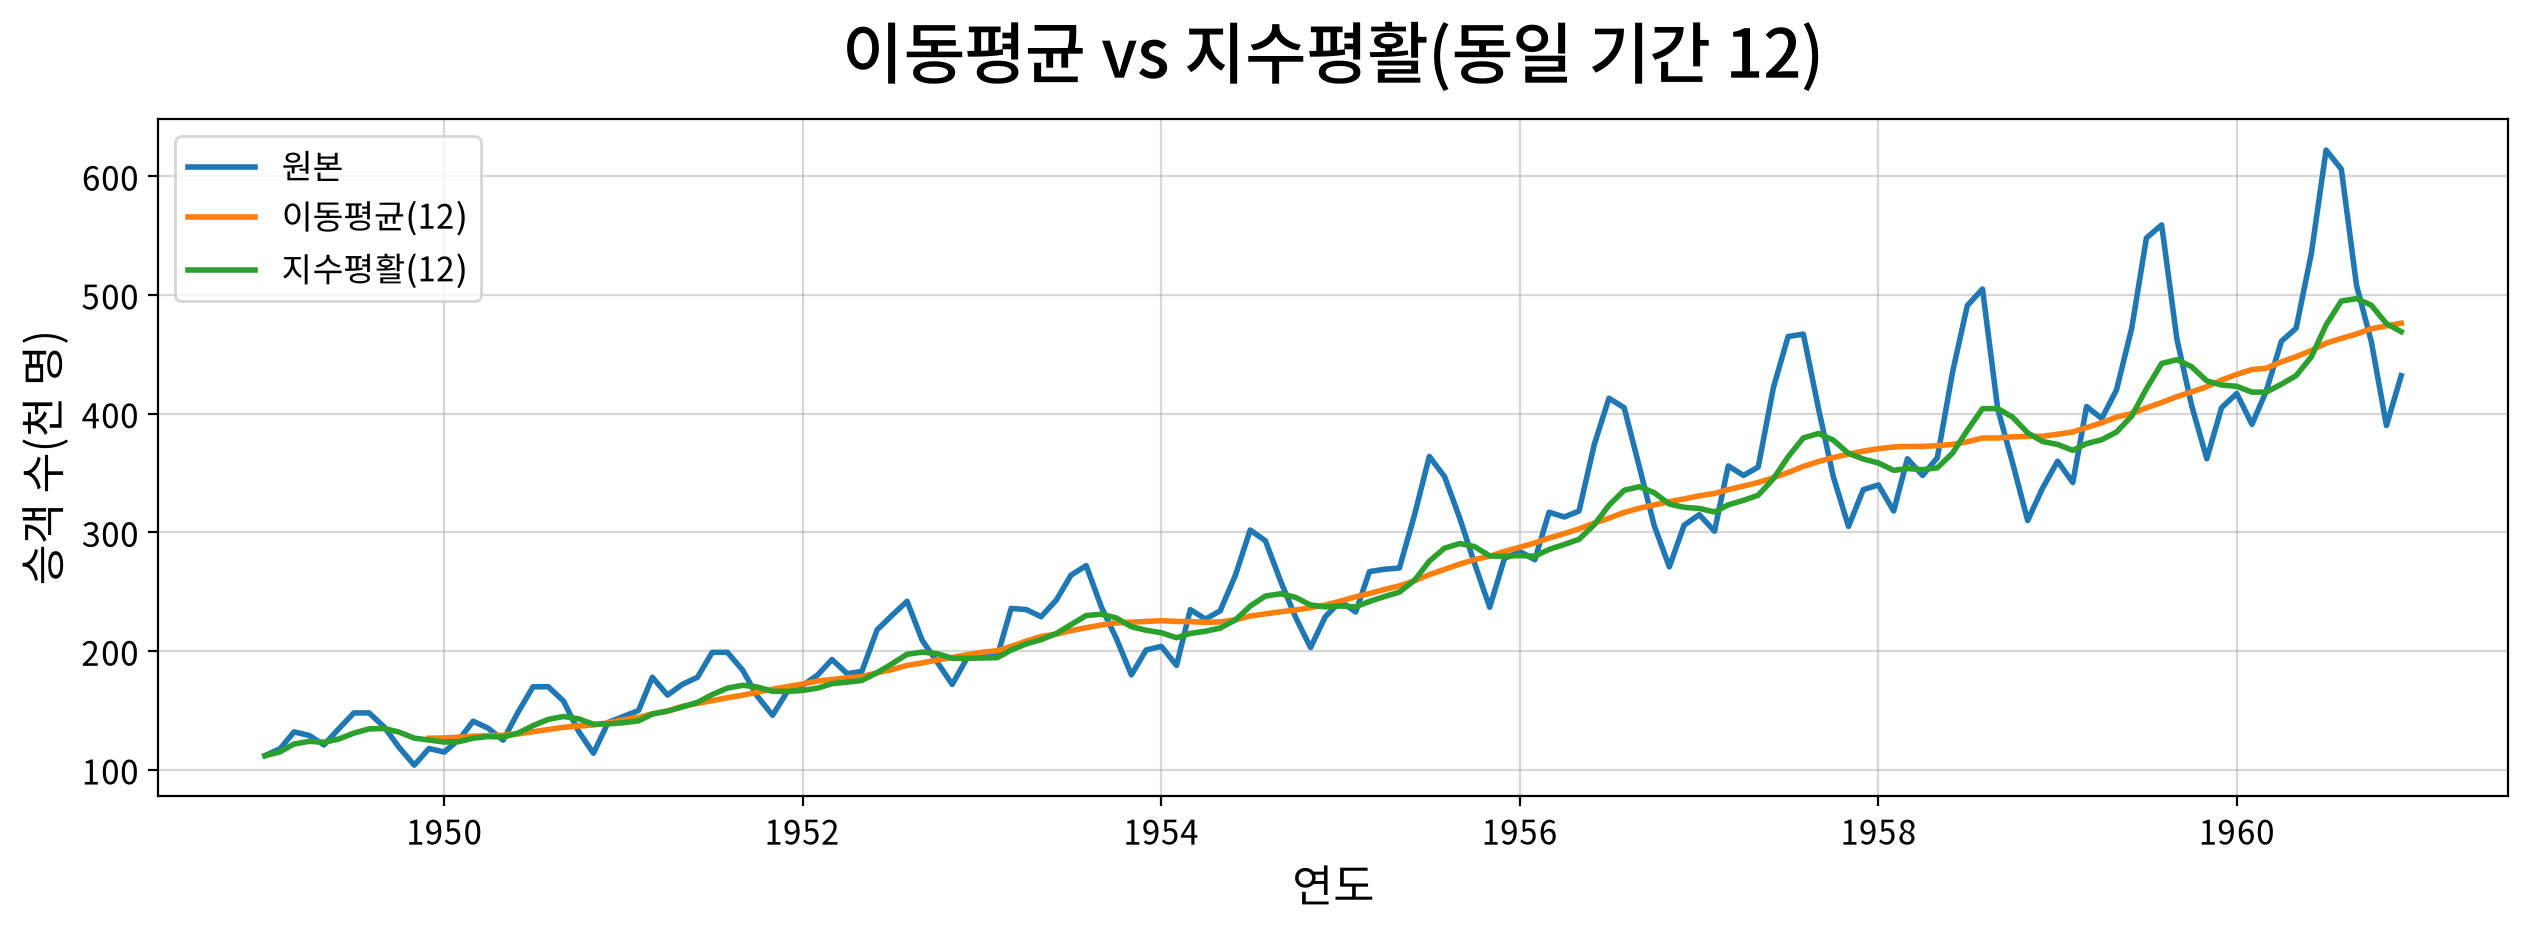

,원본,이동평균(12),지수평활(12)
Month,,,
1949-01-01,112,NaN,112.000
1949-02-01,118,NaN,115.250
1949-03-01,132,NaN,121.788
1949-04-01,129,NaN,124.064
1949-05-01,121,NaN,123.232
...,...,...,...
1960-08-01,606,463.333,494.899
1960-09-01,508,467.083,496.914
1960-10-01,461,471.583,491.389


In [12]:
both_result = my_ts.compare_smoothing(df, [12], 'Passengers', method='both', overlay=True,
                                      title = '이동평균 vs 지수평활(동일 기간 12)', xlabel='연도', ylabel='승객 수(천 명)', width = 1280, height=480)

both_result